# Bars and bootstrap
One market type (5m BTC). Two ways to slice the tick stream into bars. Bootstrap to decide if either one beats a coin flip.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtester.data_loader import build_timeline

DATA_DIR = Path('../data/validation/')
data = build_timeline(data_dir=DATA_DIR, hours=4)

T0, T1 = data.timeline[0].ts_sec, data.timeline[-1].ts_sec

btc_mid = pd.Series(
    [t.btc_mid for t in data.timeline],
    index=[t.ts_sec for t in data.timeline],
    name='btc_mid',
)

settlements = [
    s for s in data.settlements.values()
    if s.interval == '5m'
    and s.market_slug.startswith('btc-updown-5m')
    and s.start_ts >= T0 and s.end_ts <= T1
]
settlements.sort(key=lambda s: s.start_ts)

def market_btc_series(s, cut_final_sec=60):
    lo, hi = s.start_ts, s.end_ts - cut_final_sec
    return btc_mid[(btc_mid.index >= lo) & (btc_mid.index < hi)]

yes_rate = sum(1 for s in settlements if s.outcome.name == 'YES') / len(settlements)
print(f'5m BTC settlements in window: {len(settlements)}')
print(f'YES outcome base rate:        {yes_rate:.3f}')

5m BTC settlements in window: 47
YES outcome base rate:        0.447


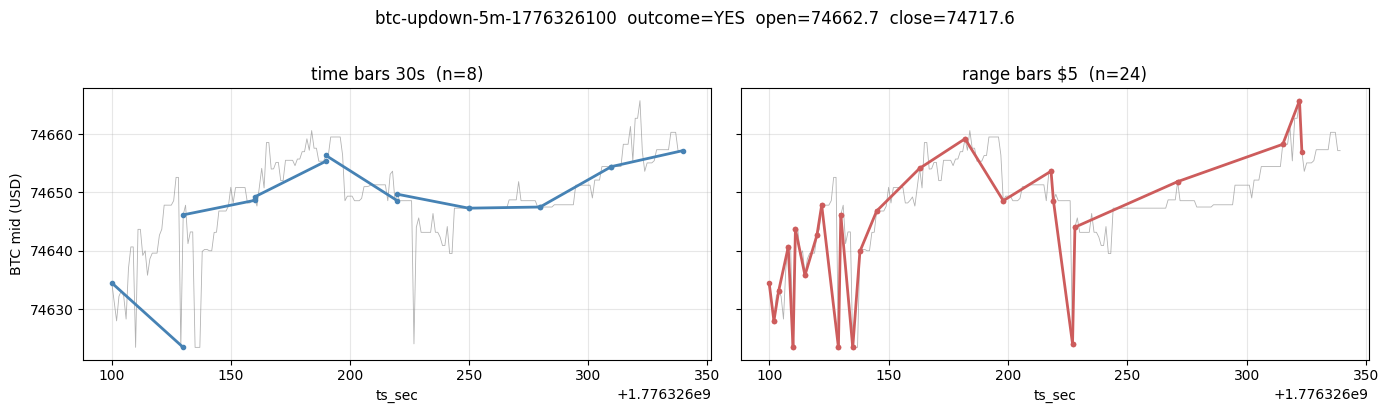

In [2]:
def time_bars(series, bar_sec=30):
    if len(series) == 0:
        return pd.DataFrame(columns=['start', 'end', 'open', 'high', 'low', 'close'])
    ts = series.index.to_numpy()
    px = series.to_numpy()
    rows = []
    b_open_t = ts[0]
    while b_open_t < ts[-1]:
        b_close_t = b_open_t + bar_sec
        mask = (ts >= b_open_t) & (ts < b_close_t)
        sub = px[mask]
        if len(sub) > 0:
            rows.append({
                'start': int(b_open_t), 'end': int(b_close_t),
                'open': sub[0], 'high': sub.max(),
                'low': sub.min(), 'close': sub[-1],
            })
        b_open_t = b_close_t
    return pd.DataFrame(rows)

def range_bars(series, range_usd=5.0):
    if len(series) == 0:
        return pd.DataFrame(columns=['start', 'end', 'open', 'high', 'low', 'close'])
    ts = series.index.to_numpy()
    px = series.to_numpy()
    rows = []
    b_open_t, b_open_p = ts[0], px[0]
    b_hi, b_lo = px[0], px[0]
    for i in range(1, len(px)):
        p, t = px[i], ts[i]
        b_hi = max(b_hi, p)
        b_lo = min(b_lo, p)
        if abs(p - b_open_p) >= range_usd:
            rows.append({
                'start': int(b_open_t), 'end': int(t),
                'open': b_open_p, 'high': b_hi,
                'low': b_lo, 'close': p,
            })
            b_open_t, b_open_p = t, p
            b_hi, b_lo = p, p
    return pd.DataFrame(rows)

example = settlements[len(settlements) // 2]
s = market_btc_series(example)
tb = time_bars(s, bar_sec=30)
rb = range_bars(s, range_usd=5.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, bars, color, title in [
    (ax1, tb, 'steelblue', f'time bars 30s  (n={len(tb)})'),
    (ax2, rb, 'indianred', f'range bars $5  (n={len(rb)})'),
]:
    ax.plot(s.index, s.values, color='grey', linewidth=0.6, alpha=0.6, label='1s ticks')
    for _, b in bars.iterrows():
        ax.plot([b['start'], b['end']], [b['open'], b['close']],
                color=color, linewidth=2, marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('ts_sec')
    ax.grid(alpha=0.3)
ax1.set_ylabel('BTC mid (USD)')
fig.suptitle(
    f'{example.market_slug}  outcome={example.outcome.name}  '
    f'open={example.chainlink_open:.1f}  close={example.chainlink_close:.1f}',
    y=1.02,
)
plt.tight_layout()
plt.show()

In [3]:
def momentum_signal(bars):
    if len(bars) == 0:
        return 0
    last = bars.iloc[-1]
    d = last['close'] - last['open']
    return 1 if d > 0 else (-1 if d < 0 else 0)

def outcome_sign(s):
    return 1 if s.outcome.name == 'YES' else -1

def collect(settlements, bar_fn, **kw):
    sigs, outs, skipped = [], [], 0
    for s in settlements:
        bars = bar_fn(market_btc_series(s), **kw)
        sig = momentum_signal(bars)
        if sig == 0:
            skipped += 1
            continue
        sigs.append(sig)
        outs.append(outcome_sign(s))
    return np.array(sigs), np.array(outs), skipped

sigs_t, outs_t, skip_t = collect(settlements, time_bars,  bar_sec=30)
sigs_r, outs_r, skip_r = collect(settlements, range_bars, range_usd=5.0)

hit_t = (sigs_t == outs_t).mean()
hit_r = (sigs_r == outs_r).mean()

pd.DataFrame([
    {'method': 'time bars 30s', 'n': len(sigs_t), 'skipped': skip_t, 'hit_rate': hit_t},
    {'method': 'range bars $5', 'n': len(sigs_r), 'skipped': skip_r, 'hit_rate': hit_r},
]).round(3)

,method,n,skipped,hit_rate
0,time bars 30s,46,1,0.674
1,range bars $5,47,0,0.596


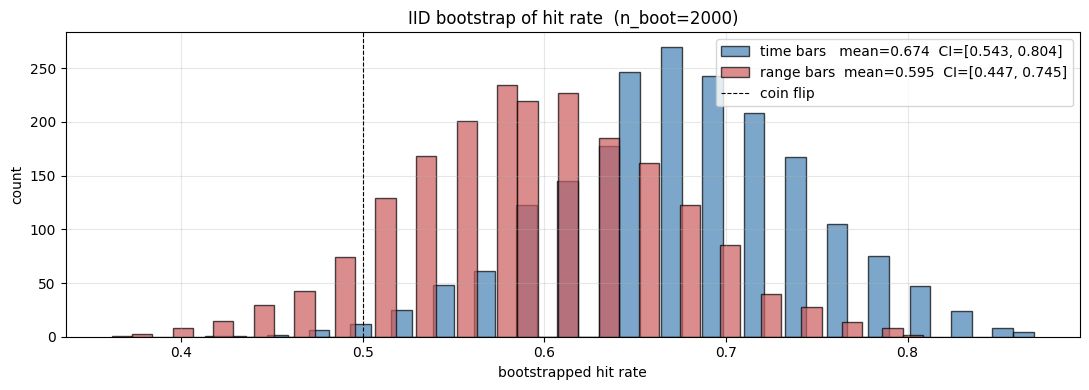

In [4]:
rng = np.random.default_rng(42)
N_BOOT = 2000

def bootstrap_hit(sigs, outs, n_boot=N_BOOT):
    hits = (sigs == outs).astype(int)
    return np.array([
        rng.choice(hits, size=len(hits), replace=True).mean()
        for _ in range(n_boot)
    ])

boot_t = bootstrap_hit(sigs_t, outs_t)
boot_r = bootstrap_hit(sigs_r, outs_r)
ci_t = np.percentile(boot_t, [2.5, 97.5])
ci_r = np.percentile(boot_r, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(boot_t, bins=40, color='steelblue', alpha=0.7, edgecolor='black',
        label=f'time bars   mean={boot_t.mean():.3f}  CI=[{ci_t[0]:.3f}, {ci_t[1]:.3f}]')
ax.hist(boot_r, bins=40, color='indianred', alpha=0.7, edgecolor='black',
        label=f'range bars  mean={boot_r.mean():.3f}  CI=[{ci_r[0]:.3f}, {ci_r[1]:.3f}]')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='coin flip')
ax.set_xlabel('bootstrapped hit rate')
ax.set_ylabel('count')
ax.set_title(f'IID bootstrap of hit rate  (n_boot={N_BOOT})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

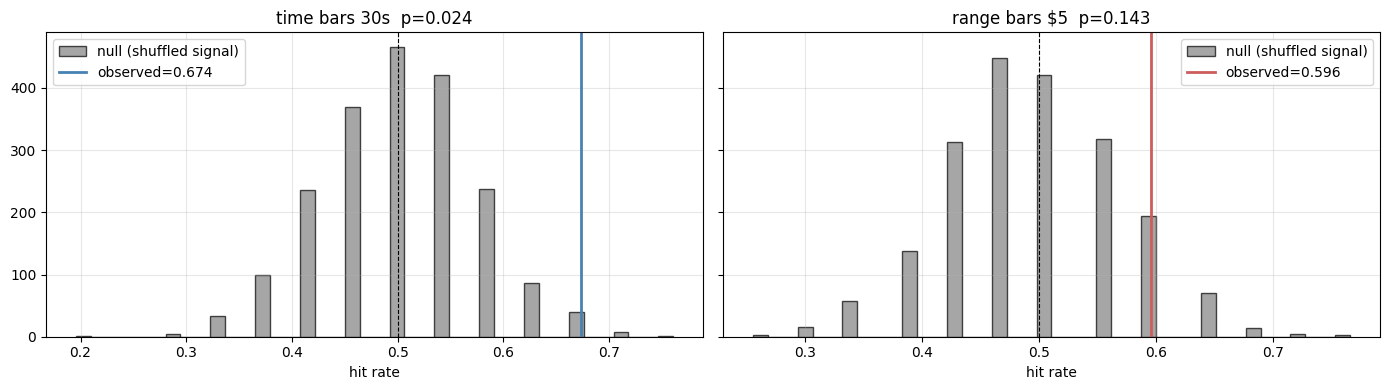

In [5]:
N_PERM = 2000

def permutation_null(sigs, outs, n_perm=N_PERM):
    observed = (sigs == outs).mean()
    null = np.array([
        (rng.permutation(sigs) == outs).mean()
        for _ in range(n_perm)
    ])
    p = (null >= observed).mean()
    return observed, null, p

obs_t, null_t, p_t = permutation_null(sigs_t, outs_t)
obs_r, null_r, p_r = permutation_null(sigs_r, outs_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, null, obs, p, title, color in [
    (axes[0], null_t, obs_t, p_t, 'time bars 30s', 'steelblue'),
    (axes[1], null_r, obs_r, p_r, 'range bars $5', 'indianred'),
]:
    ax.hist(null, bins=40, color='grey', alpha=0.7, edgecolor='black',
            label='null (shuffled signal)')
    ax.axvline(obs, color=color, linewidth=2, label=f'observed={obs:.3f}')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{title}  p={p:.3f}')
    ax.set_xlabel('hit rate')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
pd.DataFrame([
    {
        'method':    'time bars 30s',
        'n':         len(sigs_t),
        'skipped':   skip_t,
        'hit_rate':  hit_t,
        'boot_mean': boot_t.mean(),
        'ci_lo':     ci_t[0],
        'ci_hi':     ci_t[1],
        'perm_p':    p_t,
    },
    {
        'method':    'range bars $5',
        'n':         len(sigs_r),
        'skipped':   skip_r,
        'hit_rate':  hit_r,
        'boot_mean': boot_r.mean(),
        'ci_lo':     ci_r[0],
        'ci_hi':     ci_r[1],
        'perm_p':    p_r,
    },
]).round(3)

,method,n,skipped,hit_rate,boot_mean,ci_lo,ci_hi,perm_p
0,time bars 30s,46,1,0.674,0.674,0.543,0.804,0.024
1,range bars $5,47,0,0.596,0.595,0.447,0.745,0.143
